In [8]:
#------------------- Change working directory to project root -------------------#
from pathlib import Path, os

cur = Path().resolve()
while not (cur / "src").is_dir():
    if cur == cur.parent: raise RuntimeError("No 'src' dir")
    cur = cur.parent

os.chdir(cur)
print(f"[INFO] Changed working directory to project root: {cur}")

[INFO] Changed working directory to project root: /home/fernando/Documents/LoRaPriv


In [9]:
# -------------------------------------- External Libraries --------------------------------------
import numpy as np
import matplotlib.pyplot as plt
# ----------------------------------------- Local Imports ----------------------------------------
from src.core                  import LoRaPhyParams, LoRaFrameParams
from src.codec                 import LoRaCodec
from src.mod                   import LoRaModulator, plot_frame
from src.demod                 import LoRaDemodulator, plot_demodulation
from src.sync                  import DechirpBasedSynchronizer
from src.sync                  import plot_synchronization

import src.core.sdr_utils      as sdr_utils
import src.core.snr_utils      as snr_utils
import src.core.vpn_utils      as vpn_utils
import src.core.misc_utils     as misc_utils
import src.core.perf_metrics_utils as perf_utils

In [ ]:
def get_perf_metrics(channel_fn_id, filename):
    filename = f"{channel_fn_id}/{filename}.json"
    return perf_utils.SNRPerformanceMetrics.load(filename)

def plot_and_show_metric(perf_metric):
    fig, axs = plt.subplots(1, 1, figsize=(15, 8))
    logscale = not "async" in perf_metric.channel_function
    perf_utils.plot_snr_performance(perf_metric, ax=axs, logscale=logscale)
    perf_utils.annotate_perf_metadata(perf_metric, ax=axs)
    if "async" in perf_metric.channel_function:
        fold_mode_to_show = perf_metric.profile.fold_mode.upper() if perf_metric.profile.fold_mode != "0FPA" else "FPA"
        perf_utils.plot_theoric_perf(axs, fold_mode_to_show=fold_mode_to_show)
    fig.tight_layout()
    plt.show()

def compare_metrics(perf_metric_1, perf_metric_2, ax, logscale, fold_mode):
    perf_utils.plot_snr_performance(perf_metric_1, ax=ax, logscale=logscale)
    perf_utils.plot_snr_performance(perf_metric_2, ax=ax, logscale=logscale)

def plot(perf_metric, ax, logscale, fold_mode, use_fn):
    if use_fn == "plot":
        perf_utils.plot_snr_performance(perf_metric, ax=ax, logscale=logscale)
    elif use_fn == "theoric":
        perf_utils.plot_theoric_perf(ax, fold_mode_to_show=fold_mode)
    elif use_fn == "annotate":
        perf_utils.annotate_perf_metadata(perf_metric, ax=ax)

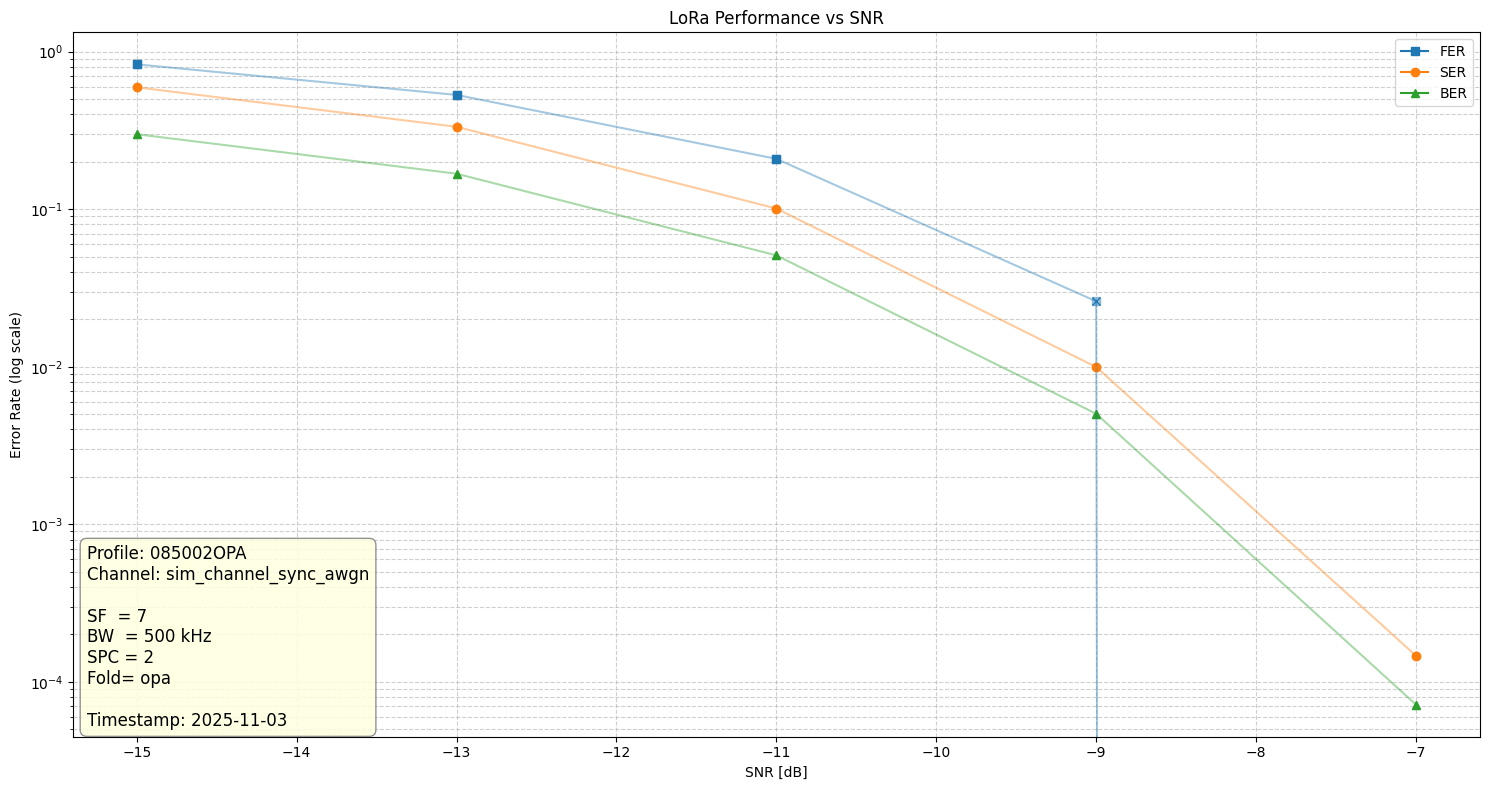

In [11]:
metrics = get_perf_metrics("sim_sync_awgn", "opa/corr/profile_20251103_085002OPA")

plot_and_show_metric(metrics)

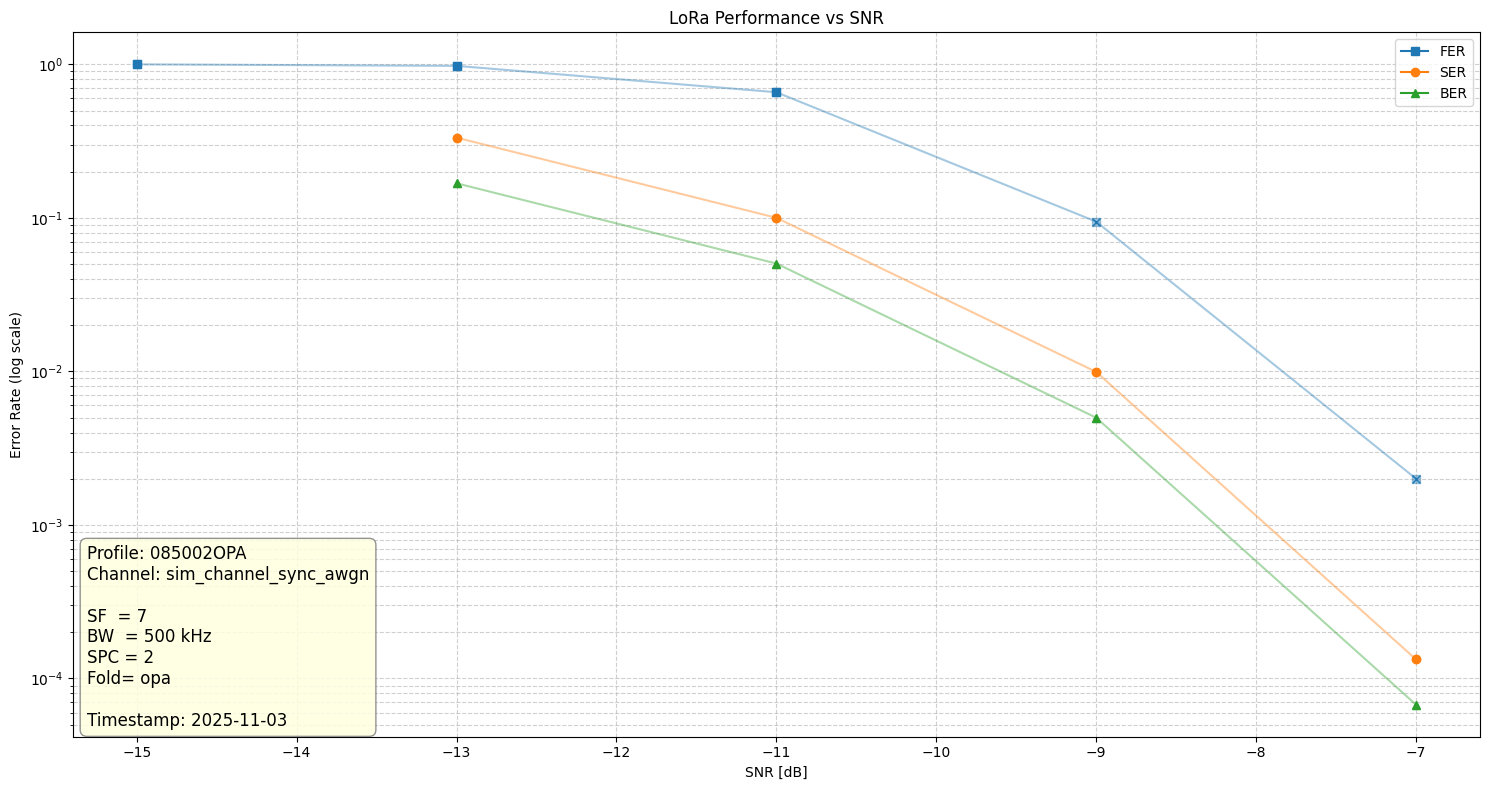

In [12]:
metrics = get_perf_metrics("sim_sync_awgn", "opa/dech/profile_20251103_085002OPA")

plot_and_show_metric(metrics)

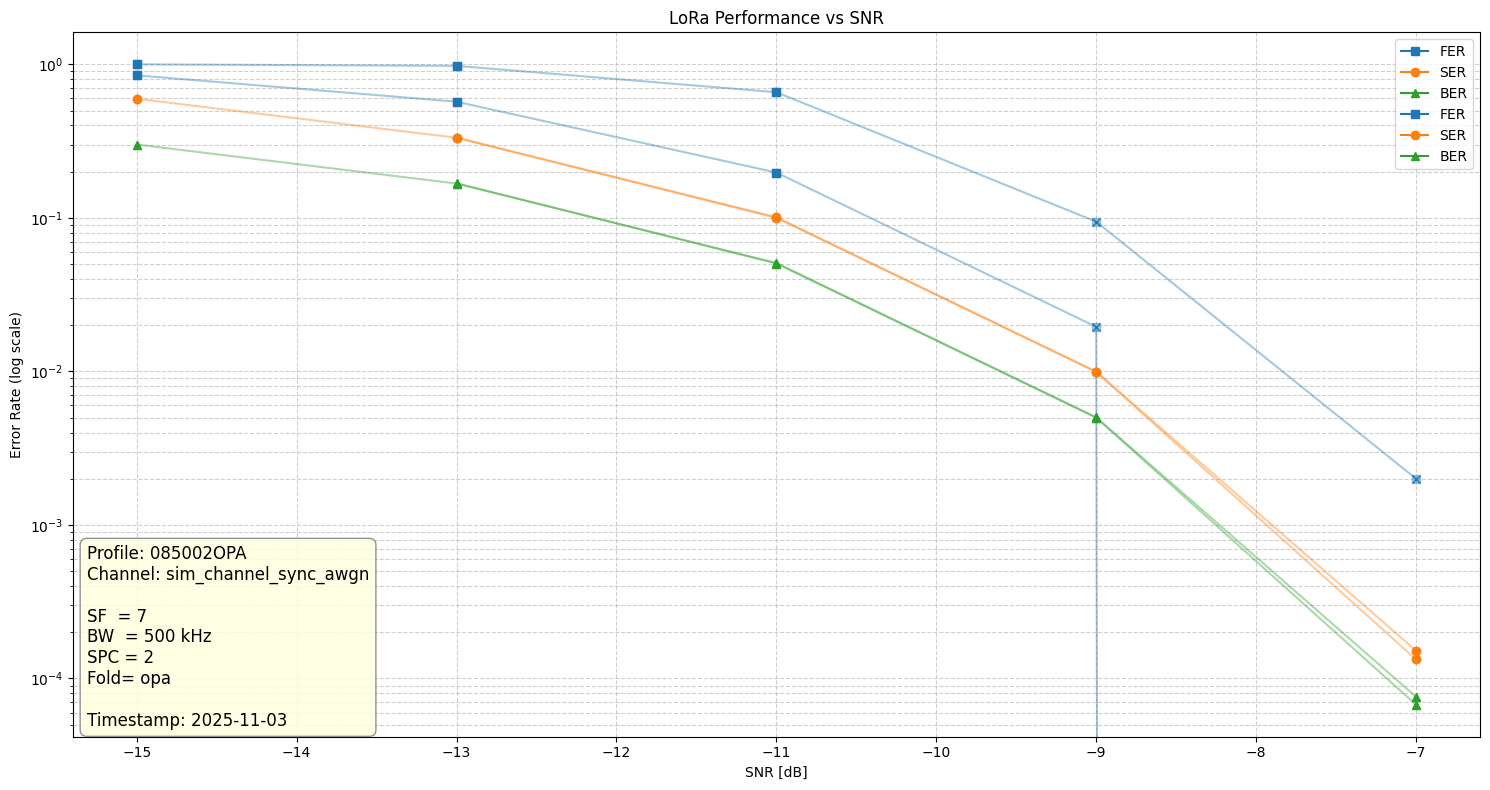

In [17]:
# Compare both metrics
fig, axs = plt.subplots(1, 1, figsize=(15, 8))
logscale = not "async" in metrics.channel_function
fold_mode = metrics.profile.fold_mode.upper() if metrics.profile.fold_mode != "0FPA" else "FPA"
compare_metrics(get_perf_metrics("sim_sync_awgn", "opa/corr/profile_20251103_085002OPA"), metrics, ax=axs, logscale=logscale, fold_mode=fold_mode)
plot(metrics, axs, logscale, fold_mode, use_fn="annotate")
plot(metrics, axs, logscale, fold_mode, use_fn="theoric")
fig.tight_layout()
plt.show()